In [56]:
import pandas as pd
import numpy as np
import re
from datetime import datetime
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
prev_years_df = pd.read_csv("ice_removals_fy12-23ytd2.csv", sep="|")

/var/folders/3l/bswlzkdn5399bd0nf3pvqfm40000gn/T/ipykernel_11201/1949459585.py:1: DtypeWarning: Columns (2,3,4,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  prev_years_df = pd.read_csv("ice_removals_fy12-23ytd2.csv", sep="|")


In [3]:
'''
files = [
    "2023-ICFO_42034_Removals_FY13-12_LESA-STU_FINAL- Redacted_raw.xlsx",
    "2023-ICFO_42034_Removals_FY16-14_LESA-STU_Final_Redacted_raw.xlsx",
    "2023-ICFO_42034_Removals_FY19-17_LESA-STU_Final_Redacted_raw.xlsx",
    "2023-ICFO_42034_Removals_FY23-20_LESA-STU_Final_Redacted_raw.xlsx"
]

all_dfs = []

for file in files:
    sheets_dict = pd.read_excel(
        file,
        sheet_name=None,   # <- this loads all sheets at once
        skiprows=5,
        engine="openpyxl"
    )
    for sheet_name, df in sheets_dict.items():
        all_dfs.append(df) 

# Combine everything
prev_years_df = pd.concat(all_dfs, ignore_index=True)

print(prev_years_df.shape)
'''

'\nfiles = [\n    "2023-ICFO_42034_Removals_FY13-12_LESA-STU_FINAL- Redacted_raw.xlsx",\n    "2023-ICFO_42034_Removals_FY16-14_LESA-STU_Final_Redacted_raw.xlsx",\n    "2023-ICFO_42034_Removals_FY19-17_LESA-STU_Final_Redacted_raw.xlsx",\n    "2023-ICFO_42034_Removals_FY23-20_LESA-STU_Final_Redacted_raw.xlsx"\n]\n\nall_dfs = []\n\nfor file in files:\n    sheets_dict = pd.read_excel(\n        file,\n        sheet_name=None,   # <- this loads all sheets at once\n        skiprows=5,\n        engine="openpyxl"\n    )\n    for sheet_name, df in sheets_dict.items():\n        all_dfs.append(df) \n\n# Combine everything\nprev_years_df = pd.concat(all_dfs, ignore_index=True)\n\nprint(prev_years_df.shape)\n'

In [4]:
prev_years_df["departed_date"] = pd.to_datetime(
    prev_years_df["departed_date"],
    format="%m/%d/%Y",   # optional but faster if consistent
    errors="coerce"
)

# Create a NEW column with just the year
prev_years_df["departed_year"] = (
    prev_years_df["departed_date"]
    .dt.year
    .astype("Int64")     # keeps missing values clean
)

prev_years_df_modif = prev_years_df[["departed_year", "citizenship_country"]]
print(prev_years_df_modif.head())


   departed_year citizenship_country
0           2012              MEXICO
1           2011              MEXICO
2           2012              MEXICO
3           2012           GUATEMALA
4           2012              MEXICO


In [5]:
df = IR_df = pd.read_csv("ICERemovalData_RecentYears.csv",
                        encoding='latin-1')

In [6]:
ctdc = pd.read_csv("CTDC_global_synthetic_data_v2025.csv")

In [7]:
print(df.head())
#print(ctdc.head())

  Arresting Agency          Criminality Area of Responsibility (AOR)  \
0              CBP  Criminal Conviction                      Atlanta   
1              CBP  Criminal Conviction                      Atlanta   
2              CBP  Criminal Conviction                      Atlanta   
3              CBP  Criminal Conviction                      Atlanta   
4              CBP  Criminal Conviction                      Atlanta   

  Country of Citizenship  Fiscal Year  Fiscal Quarter  Fiscal Month  \
0            EL SALVADOR         2024               2             4   
1              GUATEMALA         2021               1             1   
2              GUATEMALA         2021               1             2   
3              GUATEMALA         2023               1             2   
4              GUATEMALA         2023               2             4   

  Month-Year  Removals  
0   Jan 2024        10  
1   Oct 2020        25  
2   Nov 2020        18  
3   Nov 2022        13  
4   Jan 2023   

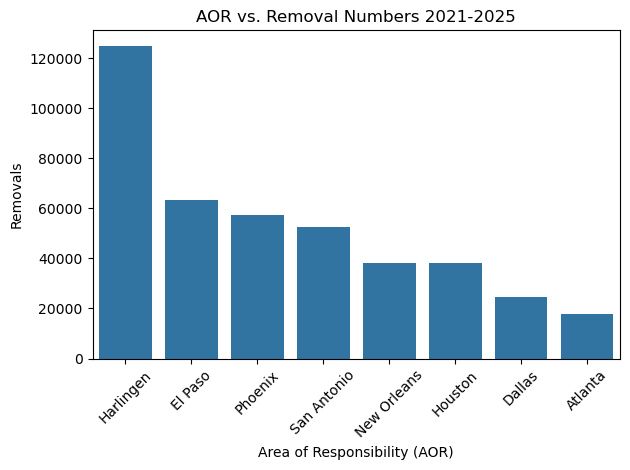

In [8]:
country_totals = df.groupby('Area of Responsibility (AOR)')['Removals'].sum().reset_index()
country_totals = country_totals.sort_values('Removals', ascending=False).head(8)

sns.barplot(data=country_totals, x='Area of Responsibility (AOR)', y='Removals')
plt.title('AOR vs. Removal Numbers 2021-2025')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
print(country_totals)

   Area of Responsibility (AOR)  Removals
10                    Harlingen    124986
8                       El Paso     63563
18                      Phoenix     57576
20                  San Antonio     52586
14                  New Orleans     38159
11                      Houston     38037
5                        Dallas     24407
0                       Atlanta     17635


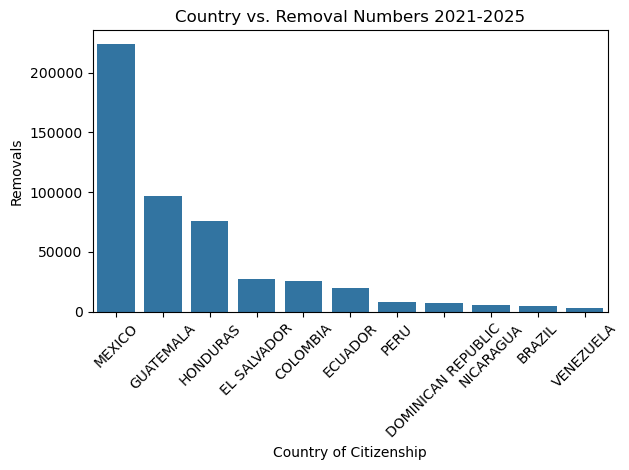

In [10]:
country_totals = df.groupby('Country of Citizenship')['Removals'].sum().reset_index()
country_totals = country_totals.sort_values('Removals', ascending=False).head(11)

sns.barplot(data=country_totals, x='Country of Citizenship', y='Removals')
plt.title('Country vs. Removal Numbers 2021-2025')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
df_TOPAOR = df[df['Area of Responsibility (AOR)'].isin(country_totals['Area of Responsibility (AOR)'])]
print(df_TOPAOR.head())

KeyError: 'Area of Responsibility (AOR)'

In [ ]:
#Line Column for Change By Year
sns.lineplot(data=df_TOPAOR, x='Month-Year', y='Removals', hue='Area of Responsibility (AOR)')
plt.title('Removals Over Time by AOR')
plt.xlabel('Month-Year')
plt.xticks(rotation=45)
plt.ylabel('Removals')
plt.tight_layout()
plt.show()

NameError: name 'df_TOPAOR' is not defined

In [13]:
prev_country_year_counts = (
    prev_years_df_modif
        .groupby(["departed_year", "citizenship_country"])
        .size()
        .reset_index(name="frequency")
)

print(prev_country_year_counts.head())

   departed_year citizenship_country  frequency
0           2010             ALBANIA          1
1           2010           ARGENTINA          3
2           2010             ARMENIA          2
3           2010             BAHAMAS          1
4           2010          BANGLADESH          4


In [14]:
iso = pd.read_csv("ISO_codes.csv")
iso = iso[["name", "alpha-3"]]

anti_join = prev_country_year_counts[
    ~prev_country_year_counts["citizenship_country"].str.lower().isin(
        iso["name"].str.lower()
    )
]
print(anti_join["citizenship_country"].unique())

iso_mapping = dict(zip(iso["name"].str.lower(), iso["name"]))

manual_mappings = {
'bolivia': 'Bolivia, Plurinational State of',
    'burma': 'Myanmar',
    'china, peoples republic of': 'China',
    'iran': 'Iran, Islamic Republic of',
    'korea': 'Korea, Republic of',
    'laos': 'Lao People\'s Democratic Republic',
    'netherlands': 'Netherlands, Kingdom of the',
    'russia': 'Russian Federation',
    'serbia and montenegro': 'Serbia',
    'south korea': 'Korea, Republic of',
    'syria': 'Syrian Arab Republic',
    'taiwan': 'Taiwan, Province of China',
    'turkey': 'Türkiye',
    'united kingdom': 'United Kingdom of Great Britain and Northern Ireland',
    'venezuela': 'Venezuela, Bolivarian Republic of',
    'vietnam': 'Viet Nam',
    'yugoslavia': 'Serbia',
    'antigua-barbuda': 'Antigua and Barbuda',
    'bosnia-herzegovina': 'Bosnia and Herzegovina',
    'british virgin islands': 'Virgin Islands (British)',
    'cape verde': 'Cabo Verde',
    'czech republic': 'Czechia',
    'czechoslovakia': 'Czechia',
    'dem rep of the congo': 'Congo, Democratic Republic of the',
    'ivory coast': 'Côte d\'Ivoire',
    'macedonia': 'North Macedonia',
    'moldova': 'Moldova, Republic of',
    'st. kitts-nevis': 'Saint Kitts and Nevis',
    'st. lucia': 'Saint Lucia',
    'st. vincent-grenadines': 'Saint Vincent and the Grenadines',
    'tanzania': 'Tanzania, United Republic of',
    'netherlands antilles': 'Curaçao',
    'ussr': 'Russian Federation',
    'swaziland': 'Eswatini',
    'macau': 'Macao',
    'north korea': 'Korea, Democratic People\'s Republic of'
}

def map_country(country):
    country_lower = country.lower()
    if country_lower in manual_mappings:
        return manual_mappings[country_lower]
    return iso_mapping.get(country_lower, country)

prev_country_year_counts["citizenship_country"] = prev_country_year_counts["citizenship_country"].apply(map_country)

anti_join = prev_country_year_counts[
    ~prev_country_year_counts["citizenship_country"].str.lower().isin(
        iso["name"].str.lower()
    )
]
print(anti_join["citizenship_country"].unique())

print(prev_country_year_counts.head())

prev_country_year_counts = prev_country_year_counts.merge(
    iso[["name", "alpha-3"]],
    left_on="citizenship_country",
    right_on="name",
    how="left"
)
prev_country_year_counts = prev_country_year_counts.drop(columns=["name"])
print(prev_country_year_counts.head())


['BOLIVIA' 'BURMA' 'CHINA, PEOPLES REPUBLIC OF' 'IRAN' 'KOREA' 'LAOS'
 'NETHERLANDS' 'RUSSIA' 'SERBIA AND MONTENEGRO' 'SOUTH KOREA' 'SYRIA'
 'TAIWAN' 'TURKEY' 'UNITED KINGDOM' 'VENEZUELA' 'VIETNAM' 'YUGOSLAVIA'
 'ANTIGUA-BARBUDA' 'BOSNIA-HERZEGOVINA' 'BRITISH VIRGIN ISLANDS'
 'CAPE VERDE' 'CZECH REPUBLIC' 'CZECHOSLOVAKIA' 'DEM REP OF THE CONGO'
 'IVORY COAST' 'KOSOVO' 'MACEDONIA' 'MOLDOVA' 'ST. KITTS-NEVIS'
 'ST. LUCIA' 'ST. VINCENT-GRENADINES' 'TANZANIA' 'UNKNOWN'
 'NETHERLANDS ANTILLES' 'USSR' 'SWAZILAND' 'MACAU' 'NORTH KOREA']
['KOSOVO' 'UNKNOWN']
   departed_year citizenship_country  frequency
0           2010             Albania          1
1           2010           Argentina          3
2           2010             Armenia          2
3           2010             Bahamas          1
4           2010          Bangladesh          4
   departed_year citizenship_country  frequency alpha-3
0           2010             Albania          1     ALB
1           2010           Argentina       

In [15]:
prev_country_year_counts

,departed_year,citizenship_country,frequency,alpha-3
0,2010,Albania,1,ALB
1,2010,Argentina,3,ARG
2,2010,Armenia,2,ARM
3,2010,Bahamas,1,BHS
4,2010,Bangladesh,4,BGD
...,...,...,...,...
2330,2023,United Kingdom of Great Britain and Northern I...,5,GBR
2331,2023,Uruguay,1,URY
2332,2023,Uzbekistan,4,UZB
2333,2023,"Venezuela, Bolivarian Republic of",34,VEN


In [16]:
removals_df = (
    df
    .groupby(
        ["Country of Citizenship", "Fiscal Year"]
    )
    .size()
    .reset_index(name="Number of Records")
)

print(removals_df.head())

  Country of Citizenship  Fiscal Year  Number of Records
0            AFGHANISTAN         2024                  3
1            AFGHANISTAN         2025                  1
2                 ANGOLA         2023                  1
3                 ANGOLA         2024                  1
4             BANGLADESH         2024                  6


In [17]:
ctdc["start_year"] = ctdc["traffickMonths"].str.extract(r'\((.*?)\)', expand=False)
ctdc["start_year"] = ctdc["start_year"].str.replace(r'\s*yrs?', '', regex=True)
ctdc = ctdc[ctdc["start_year"] == "0-1"]

In [18]:
ctdc_clean = ctdc.groupby(["citizenship", "yearOfRegistration"]).size().reset_index(name="count")
print(ctdc_clean['yearOfRegistration'].unique())


[2003. 2010. 2013. 2014. 2017. 2018. 2020. 2009. 2015. 2019. 2021. 2023.
 2016. 2002. 2008. 2011. 2012. 2022. 2006. 2005.]


In [19]:
ctdc = ctdc.dropna(subset=["yearOfRegistration"])
ctdc["yearOfRegistration"] = ctdc["yearOfRegistration"].astype(int)
ctdc["yearOfRegistration"].dtype

ctdc.head()

ctdc_grouped = ctdc.groupby(["citizenship", "yearOfRegistration"]).size().reset_index(name="count")
ctdc_grouped.head()


,citizenship,yearOfRegistration,count
0,AFG,2003,1
1,AFG,2010,1
2,AFG,2013,38
3,AFG,2014,83
4,AFG,2017,1


In [21]:
removals_df = removals_df.rename(columns={
    "Country of Citizenship": "CountryOfCitizenship",
    "Fiscal Year": "FiscalYear",
    "Number of Records": "Frequency"
})

iso = iso[["name", "alpha-3"]]

anti_join = removals_df[
    ~removals_df["CountryOfCitizenship"].str.lower().isin(
        iso["name"].str.lower()
    )
]
print(anti_join["CountryOfCitizenship"].unique())

country_mapping = {
    "CHINA, PEOPLES REPUBLIC OF": "China",
    "BOLIVIA": "Bolivia, Plurinational State of",
    "DEM REP OF THE CONGO": "Congo, Democratic Republic of the",
    "REPUBLIC OF TÜRKIYE": "Türkiye",
    "RUSSIA": "Russian Federation",
    "TURKIYE": "Türkiye",
    "UNITED KINGDOM": "United Kingdom of Great Britain and Northern Ireland",
    "VENEZUELA": "Venezuela, Bolivarian Republic of"
}

removals_df["CountryOfCitizenship"] = (
    removals_df["CountryOfCitizenship"]
    .replace(country_mapping)
)

anti_join = removals_df[
    ~removals_df["CountryOfCitizenship"].str.lower().isin(
        iso["name"].str.lower()
    )
]
print(anti_join["CountryOfCitizenship"].unique())

removals_df["_country_key"] = removals_df["CountryOfCitizenship"].str.strip().str.lower()
iso["_country_key"] = iso["name"].str.strip().str.lower()

removals_df = removals_df.merge(
    iso[["_country_key", "alpha-3"]],
    on="_country_key",
    how="left"
)

print(removals_df.head())

removals_df.to_csv("merged_df.csv", index=False)

['REPUBLIC OF TÃ\x9cRKIYE']
['REPUBLIC OF TÃ\x9cRKIYE']
  CountryOfCitizenship  FiscalYear  Frequency _country_key alpha-3_x alpha-3_y
0          AFGHANISTAN        2024          3  afghanistan       AFG       AFG
1          AFGHANISTAN        2025          1  afghanistan       AFG       AFG
2               ANGOLA        2023          1       angola       AGO       AGO
3               ANGOLA        2024          1       angola       AGO       AGO
4           BANGLADESH        2024          6   bangladesh       BGD       BGD


In [22]:
print(ctdc_grouped.head())
print(prev_country_year_counts.head())


  citizenship  yearOfRegistration  count
0         AFG                2003      1
1         AFG                2010      1
2         AFG                2013     38
3         AFG                2014     83
4         AFG                2017      1
   departed_year citizenship_country  frequency alpha-3
0           2010             Albania          1     ALB
1           2010           Argentina          3     ARG
2           2010             Armenia          2     ARM
3           2010             Bahamas          1     BHS
4           2010          Bangladesh          4     BGD


In [ ]:
print(ctdc_grouped.head())

ctdc_grouped.to_csv("ctdc_grouped.csv", index=False)

recent_year_mergrged = removals_df.merge(
    ctdc_grouped,
    left_on=["alpha-3_x", "FiscalYear"],
    right_on=["citizenship", "yearOfRegistration"],
    how="left",
    indicator=True
)

recent_year_mergrged["_merge"].value_counts()

print(recent_year_mergrged.head())

recent_year_mergrged = recent_year_mergrged.rename(columns={
    "Frequency": "deportee_freq",
    "count": "traffick_freq"
})

recent_year_mergrged = recent_year_mergrged.dropna(
    subset=["deportee_freq", "traffick_freq"]
)

  citizenship  yearOfRegistration  count
0         AFG                2003      1
1         AFG                2010      1
2         AFG                2013     38
3         AFG                2014     83
4         AFG                2017      1
  CountryOfCitizenship  FiscalYear  Frequency _country_key alpha-3_x  \
0          AFGHANISTAN        2024          3  afghanistan       AFG   
1          AFGHANISTAN        2025          1  afghanistan       AFG   
2               ANGOLA        2023          1       angola       AGO   
3               ANGOLA        2024          1       angola       AGO   
4           BANGLADESH        2024          6   bangladesh       BGD   

  alpha-3_y citizenship  yearOfRegistration  count     _merge  
0       AFG         NaN                 NaN    NaN  left_only  
1       AFG         NaN                 NaN    NaN  left_only  
2       AGO         NaN                 NaN    NaN  left_only  
3       AGO         NaN                 NaN    NaN  left_only  
4

In [33]:
recent_year_mergrged

,CountryOfCitizenship,FiscalYear,deportee_freq,_country_key,alpha-3_x,alpha-3_y,citizenship,yearOfRegistration,traffick_freq,_merge
10,BRAZIL,2022,40,brazil,BRA,BRA,BRA,2022.0,1.0,both
23,COLOMBIA,2022,75,colombia,COL,COL,COL,2022.0,1.0,both
24,COLOMBIA,2023,129,colombia,COL,COL,COL,2023.0,6.0,both
34,DOMINICAN REPUBLIC,2021,33,dominican republic,DOM,DOM,DOM,2021.0,2.0,both
67,INDIA,2021,3,india,IND,IND,IND,2021.0,1.0,both
69,INDIA,2023,2,india,IND,IND,IND,2023.0,1.0,both
108,SOMALIA,2021,1,somalia,SOM,SOM,SOM,2021.0,6.0,both
114,SRI LANKA,2023,1,sri lanka,LKA,LKA,LKA,2023.0,2.0,both


In [34]:
recent_year_mergrged

,CountryOfCitizenship,FiscalYear,deportee_freq,_country_key,alpha-3_x,alpha-3_y,citizenship,yearOfRegistration,traffick_freq,_merge
10,BRAZIL,2022,40,brazil,BRA,BRA,BRA,2022.0,1.0,both
23,COLOMBIA,2022,75,colombia,COL,COL,COL,2022.0,1.0,both
24,COLOMBIA,2023,129,colombia,COL,COL,COL,2023.0,6.0,both
34,DOMINICAN REPUBLIC,2021,33,dominican republic,DOM,DOM,DOM,2021.0,2.0,both
67,INDIA,2021,3,india,IND,IND,IND,2021.0,1.0,both
69,INDIA,2023,2,india,IND,IND,IND,2023.0,1.0,both
108,SOMALIA,2021,1,somalia,SOM,SOM,SOM,2021.0,6.0,both
114,SRI LANKA,2023,1,sri lanka,LKA,LKA,LKA,2023.0,2.0,both


In [26]:
prev_year_merged = prev_country_year_counts.merge(
    ctdc_grouped,
    left_on=["alpha-3", "departed_year"],
    right_on=["citizenship", "yearOfRegistration"],
    how="left",
    indicator=True
)

prev_year_merged = prev_year_merged.rename(columns={
    "frequency": "deportee_freq",
    "count": "traffick_freq"
})

prev_year_merged = prev_year_merged.dropna(
    subset=["deportee_freq", "traffick_freq"]
)

In [35]:
prev_year_merged

,departed_year,citizenship_country,deportee_freq,alpha-3,citizenship,yearOfRegistration,traffick_freq,_merge
7,2010,Myanmar,1,MMR,MMR,2010.0,3.0,both
12,2010,Colombia,18,COL,COL,2010.0,1.0,both
35,2010,Kazakhstan,2,KAZ,KAZ,2010.0,7.0,both
56,2010,Romania,3,ROU,ROU,2010.0,1.0,both
70,2010,Ukraine,2,UKR,UKR,2010.0,162.0,both
...,...,...,...,...,...,...,...,...
2316,2023,Romania,12,ROU,ROU,2023.0,1.0,both
2319,2023,Sierra Leone,1,SLE,SLE,2023.0,9.0,both
2325,2023,Thailand,3,THA,THA,2023.0,2.0,both
2329,2023,Ukraine,1,UKR,UKR,2023.0,4.0,both


In [44]:
recent_year_merged_clean = recent_year_mergrged[
    ["FiscalYear", "alpha-3_x", "deportee_freq", "traffick_freq"]
]

recent_year_merged_clean = recent_year_merged_clean.rename(columns={
    "FiscalYear": "year",
    "citizenship": "country",
    "alpha-3_x": "alpha-3"
})

In [45]:
prev_year_merged
prev_year_merged_clean = prev_year_merged[
    ["departed_year", "alpha-3", "deportee_freq", "traffick_freq"]
]

prev_year_merged_clean = prev_year_merged_clean.rename(columns={
    "departed_year": "year",
    "citizenship_country": "country"
})

In [46]:
print(recent_year_merged_clean.head())

    year alpha-3  deportee_freq  traffick_freq
10  2022     BRA             40            1.0
23  2022     COL             75            1.0
24  2023     COL            129            6.0
34  2021     DOM             33            2.0
67  2021     IND              3            1.0


In [47]:
print(prev_year_merged_clean.head())

    year alpha-3  deportee_freq  traffick_freq
7   2010     MMR              1            3.0
12  2010     COL             18            1.0
35  2010     KAZ              2            7.0
56  2010     ROU              3            1.0
70  2010     UKR              2          162.0


In [49]:
counts1 = recent_year_merged_clean.groupby("year").size()
counts2 = prev_year_merged_clean.groupby("year").size()
year_counts = pd.concat([counts1, counts2], axis=1, keys=["File 1", "File 2"])
year_counts = year_counts.fillna(0).astype(int)   # optional: replace NaN with 0
print(year_counts)

      File 1  File 2
year                
2021       3      18
2022       2      14
2023       3      12
2010       0       7
2011       0      14
2012       0       9
2013       0      19
2014       0      21
2015       0      22
2016       0      24
2017       0      21
2018       0      16
2019       0      17
2020       0      12


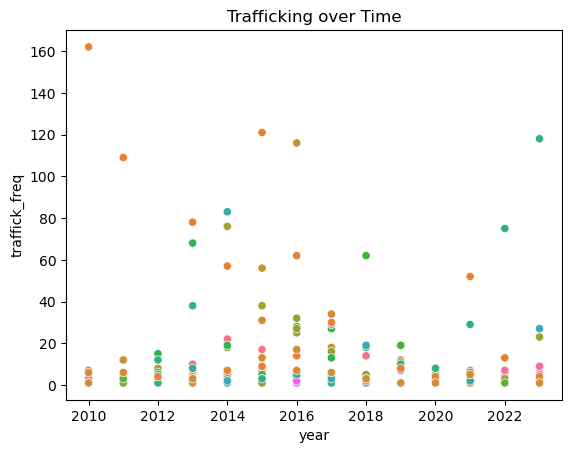

Pearson r: -0.058806036403819185


In [ ]:
sns.scatterplot(data=prev_year_merged_clean, x="year", y="traffick_freq", hue="alpha-3", legend=False)
plt.title("Trafficking over Time")
plt.show()

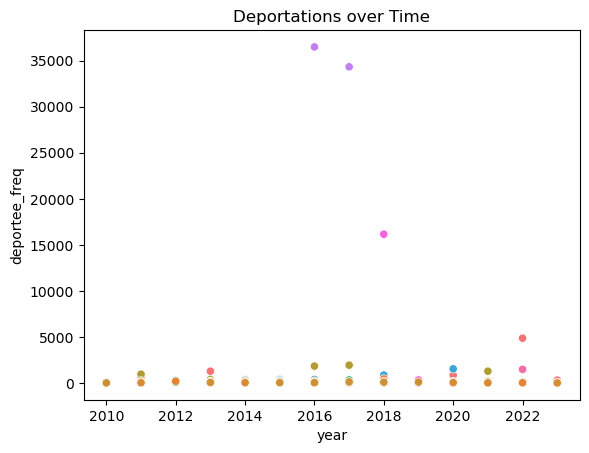

Pearson r: -0.058806036403819185


In [ ]:
sns.scatterplot(data=prev_year_merged_clean, x="year", y="deportee_freq", hue="alpha-3", legend=False)
plt.title("Deportations over Time")
plt.show()

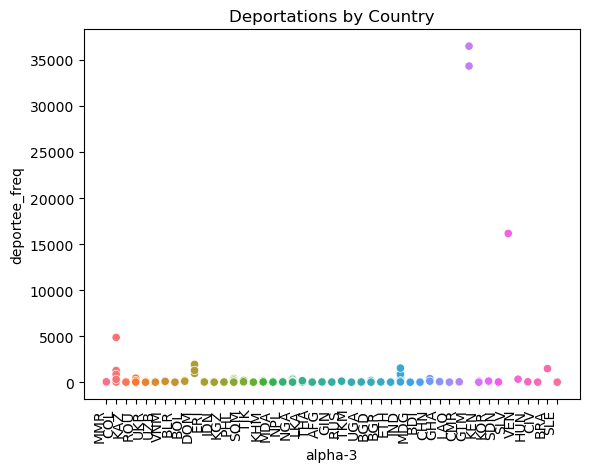

In [ ]:
sns.scatterplot(data=prev_year_merged_clean, x="alpha-3", y="deportee_freq", hue="alpha-3", legend=False)
plt.title("Deportations by Country")
plt.xticks(rotation=90, ha='right')
plt.show()

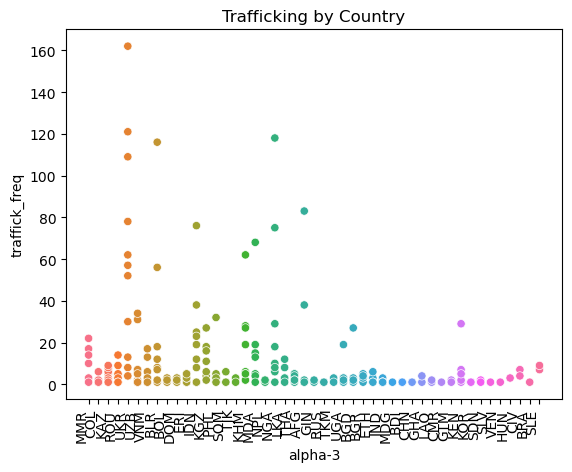

In [68]:
sns.scatterplot(data=prev_year_merged_clean, x="alpha-3", y="traffick_freq", hue="alpha-3", legend=False)
plt.title("Trafficking by Country")
plt.xticks(rotation=90, ha='right')
plt.show()

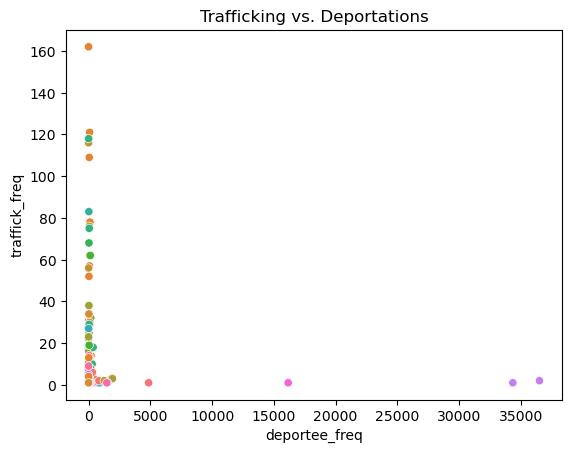

Pearson r: -0.058806036403819185


In [ ]:
sns.scatterplot(data=prev_year_merged_clean, x="deportee_freq", y="traffick_freq", hue="alpha-3", legend=False)
plt.title("Trafficking vs. Deportations")
plt.show()

In [57]:
model_simple = smf.ols('traffick_freq ~ deportee_freq', data=prev_year_merged_clean).fit()
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:          traffick_freq   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.7773
Date:                Wed, 04 Mar 2026   Prob (F-statistic):              0.379
Time:                        21:20:10   Log-Likelihood:                -1026.9
No. Observations:                 226   AIC:                             2058.
Df Residuals:                     224   BIC:                             2065.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        11.5462      1.538      7.509